# Аудит Wine Quality (White Wine)

Safari. Запуск: **Runtime → Run all**.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
print('OK: libraries loaded')

OK: libraries loaded


In [2]:
CSV_NAME = 'winequality-white.csv'
UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/winequality-white.csv'

if not os.path.exists(CSV_NAME):
    print('Downloading from UCI...')
    !wget -q -O {CSV_NAME} {UCI_URL}

if not os.path.exists(CSV_NAME):
    raise FileNotFoundError('Upload CSV via Files panel on the left.')

df = pd.read_csv(CSV_NAME, sep=';')
print('OK: dataset loaded, shape =', df.shape)
df.head()

OK: dataset loaded, shape = (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
print('=' * 60)
print('GENERAL STATS')
print('=' * 60)
print('Shape:', df.shape)
print('Features:', df.shape[1] - 1)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Describe:')
print(df.describe().T.round(3))

GENERAL STATS
Shape: (4898, 12)
Features: 11

Dtypes:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Describe:
                       count     mean     std    min      25%      50%  \
fixed acidity         4898.0    6.855   0.844  3.800    6.300    6.800   
volatile acidity      4898.0    0.278   0.101  0.080    0.210    0.260   
citric acid           4898.0    0.334   0.121  0.000    0.270    0.320   
residual sugar        4898.0    6.391   5.072  0.600    1.700    5.200   
chlorides             4898.0    0.046   0.022  0.009    0.036    0.043   
free sulfur dioxide   4898.0   35.308  17.007  2.000   23.000   34.000   
total sulfur dioxid

In [4]:
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    print('OK: missing values filled with median')
else:
    print('OK: no missing values')

OK: no missing values


In [5]:
n_dups = df.duplicated().sum()
print('Duplicates found:', n_dups, '=', round(n_dups / len(df) * 100, 2), '%')
df = df.drop_duplicates().reset_index(drop=True)
print('OK: after drop, shape =', df.shape)

Duplicates found: 937 = 19.13 %
OK: after drop, shape = (3961, 12)


In [6]:
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print('Constant columns:', const_cols if const_cols else 'none')

Constant columns: none


In [7]:
counts = df['quality'].value_counts().sort_index()
print('Class counts:')
print(counts)
print()
print('Imbalance max/min =', round(counts.max() / counts.min(), 2))

Class counts:
quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64

Imbalance max/min = 357.6


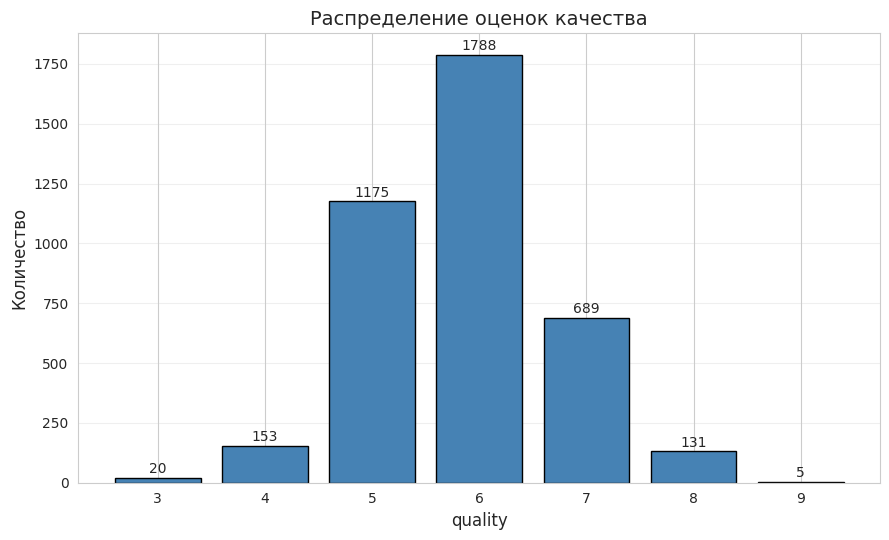

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(counts.index.astype(str), counts.values,
              color='steelblue', edgecolor='black')
ax.set_title('Распределение оценок качества', fontsize=14)
ax.set_xlabel('quality', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)
ax.grid(alpha=0.3, axis='y')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 20,
            str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('bar_quality.png', dpi=150, bbox_inches='tight')
plt.show()

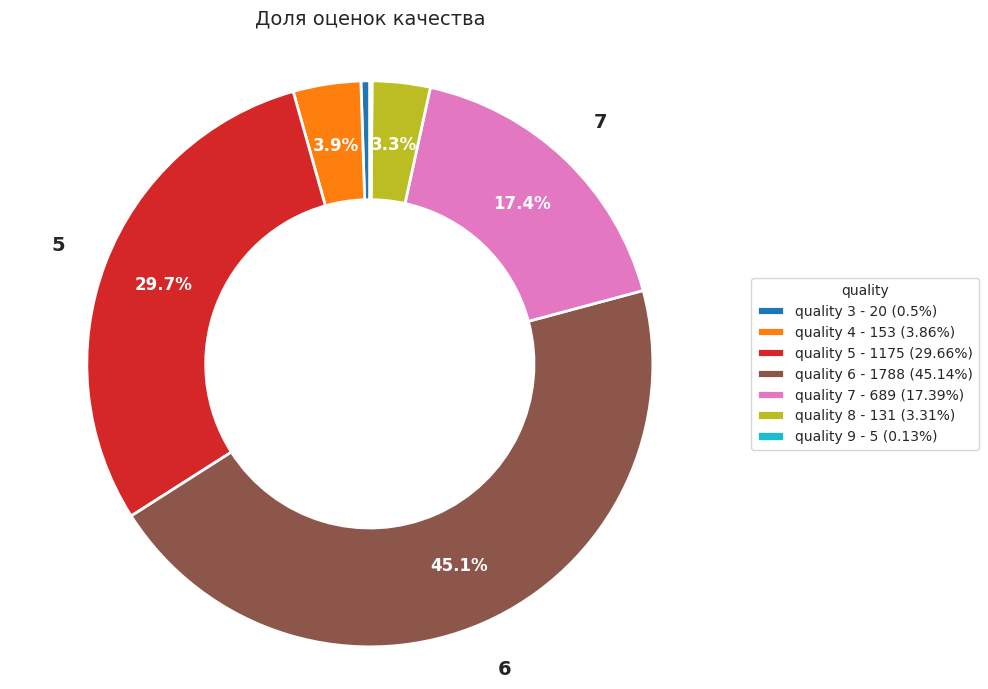

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

total = int(counts.sum())
colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))
pct_values = counts.values / total * 100

def autopct_filter(pct):
    if pct >= 3:
        return str(round(pct, 1)) + '%'
    return ''

wedges, texts, autotexts = ax.pie(
    counts.values,
    startangle=90,
    colors=colors,
    autopct=autopct_filter,
    pctdistance=0.78,
    textprops={'fontsize': 12, 'color': 'white', 'weight': 'bold'},
    wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 2}
)

for i, w in enumerate(wedges):
    pct = pct_values[i]
    if pct < 5:
        continue
    ang = np.deg2rad((w.theta2 + w.theta1) / 2)
    x = 1.18 * np.cos(ang)
    y = 1.18 * np.sin(ang)
    ax.text(x, y, str(counts.index[i]),
            ha='center', va='center',
            fontsize=14, weight='bold')

legend_labels = []
for q in counts.index:
    n = int(counts[q])
    pct = round(n / total * 100, 2)
    legend_labels.append('quality ' + str(q) + ' - ' + str(n) + ' (' + str(pct) + '%)')

ax.legend(wedges, legend_labels,
          title='quality',
          loc='center left',
          bbox_to_anchor=(1.02, 0.5),
          fontsize=10)

ax.set_title('Доля оценок качества', fontsize=14, pad=20)
ax.axis('equal')

plt.tight_layout()
plt.savefig('donut_quality.png', dpi=150, bbox_inches='tight')
plt.show()

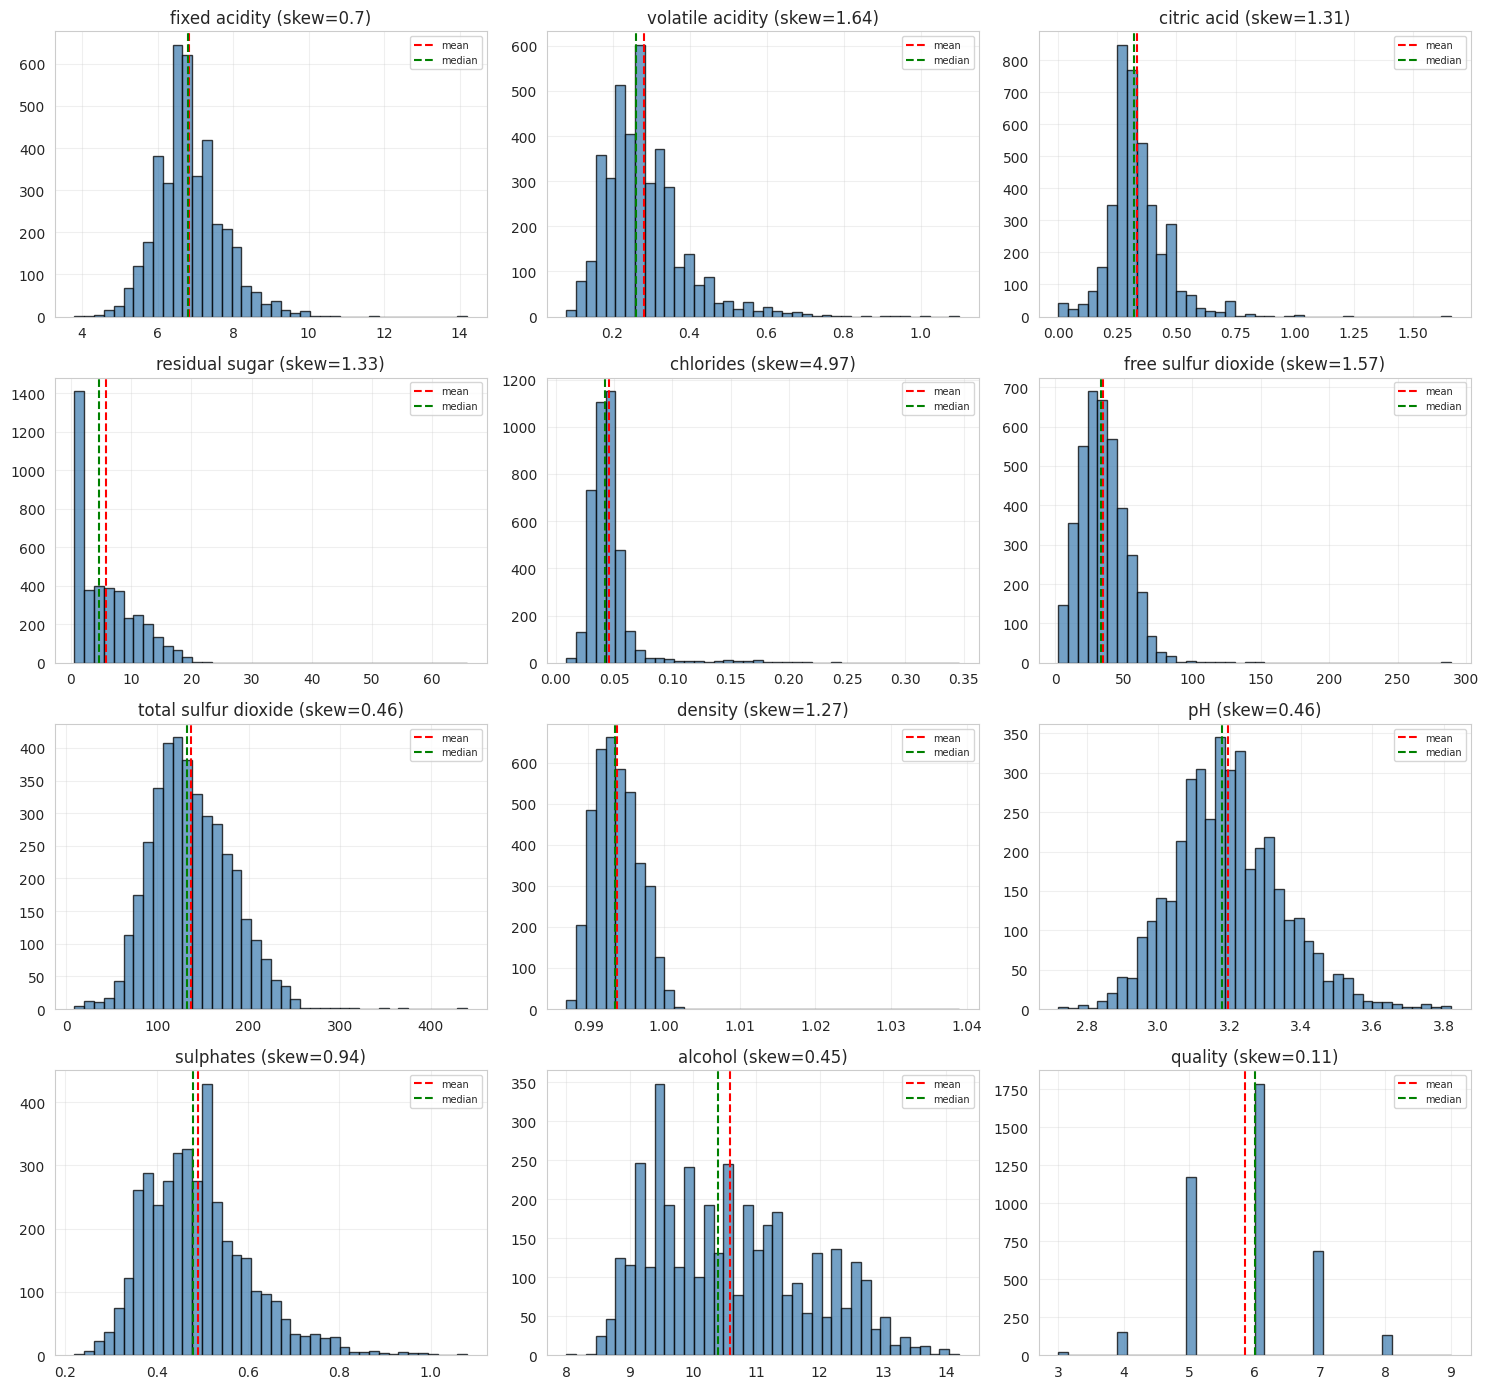

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue',
                 edgecolor='black', alpha=0.75)
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', label='mean')
    axes[i].axvline(df[col].median(), color='green',
                    linestyle='--', label='median')
    axes[i].set_title(col + ' (skew=' + str(round(df[col].skew(), 2)) + ')')
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()

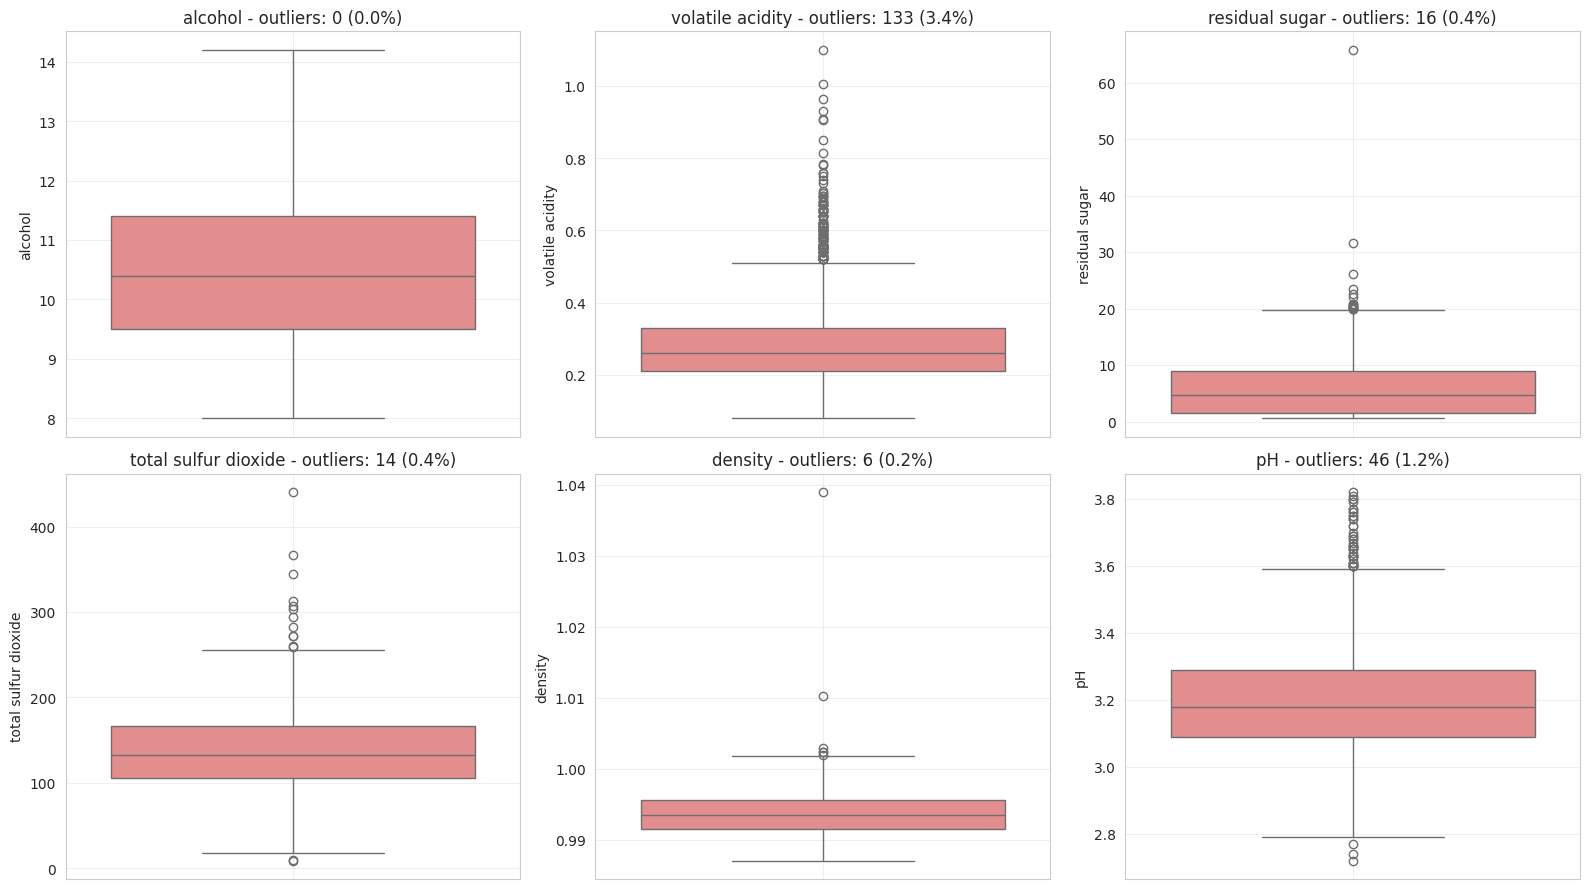

Outliers by IQR:
  alcohol: 0
  volatile acidity: 133
  residual sugar: 16
  total sulfur dioxide: 14
  density: 6
  pH: 46


In [11]:
priority = ['alcohol', 'volatile acidity', 'residual sugar',
            'total sulfur dioxide', 'density', 'pH']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
report = {}

for i, col in enumerate(priority):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    n_out = int(mask.sum())
    report[col] = n_out
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    pct = round(n_out / len(df) * 100, 1)
    axes[i].set_title(col + ' - outliers: ' + str(n_out) + ' (' + str(pct) + '%)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots_priority.png', dpi=100, bbox_inches='tight')
plt.show()

print('Outliers by IQR:')
for k, v in report.items():
    print('  ' + k + ':', v)

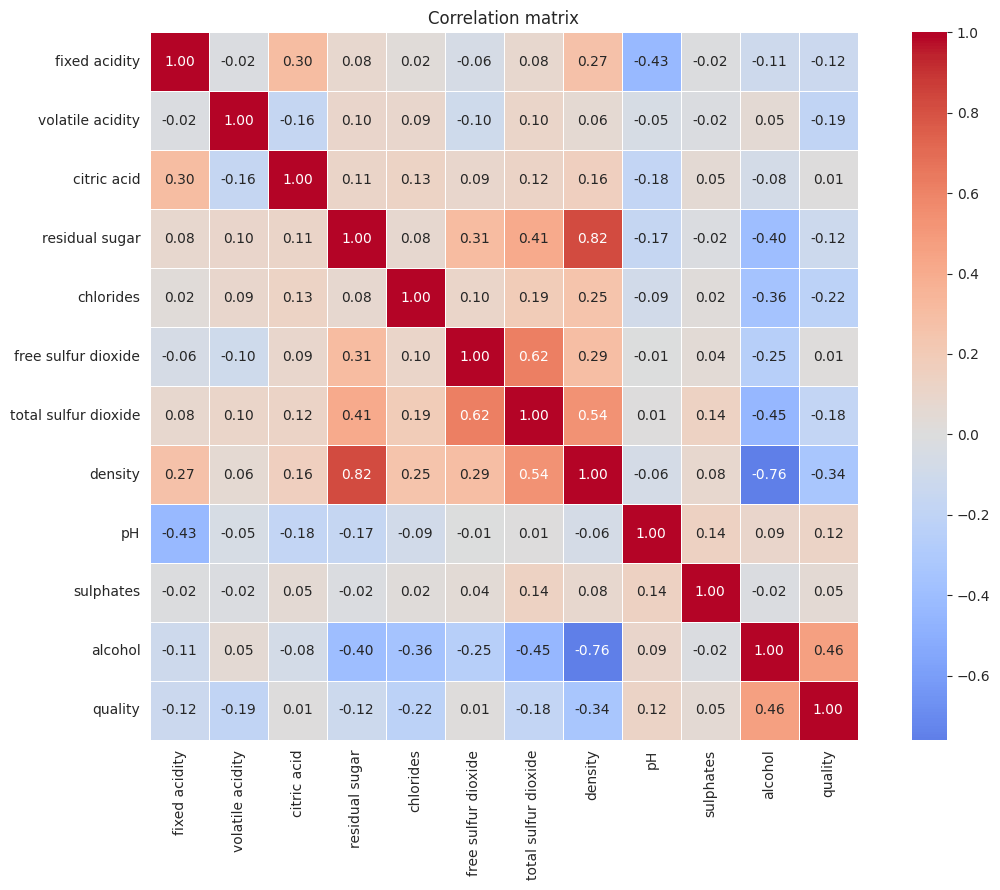

Correlation with quality:
alcohol                 0.463
density                -0.338
chlorides              -0.218
volatile acidity       -0.191
total sulfur dioxide   -0.183
fixed acidity          -0.125
pH                      0.124
residual sugar         -0.117
sulphates               0.053
free sulfur dioxide     0.011
citric acid             0.007
Name: quality, dtype: float64


In [12]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print('Correlation with quality:')
print(corr['quality'].drop('quality').sort_values(key=abs, ascending=False).round(3))

In [13]:
df.to_csv('winequality_white_clean.csv', index=False)
print('OK: saved winequality_white_clean.csv, shape =', df.shape)
print('Files: bar_quality.png, donut_quality.png, distributions.png, boxplots_priority.png, correlation.png')

OK: saved winequality_white_clean.csv, shape = (3961, 12)
Files: bar_quality.png, donut_quality.png, distributions.png, boxplots_priority.png, correlation.png


## Выводы

1. Пропусков нет.
2. Дубликаты (~19%) удалены.
3. Константных признаков нет.
4. Сильный дисбаланс классов (5 и 6 доминируют).
5. Асимметрия: residual sugar, chlorides, sulphates.
6. Выбросы больше всего в residual sugar и chlorides.
7. Топ-признаки vs quality: alcohol (+), volatile acidity (-), density (-).